Using the typing dataset (lightgbm) from that was label encoded duing preprocessing

In [3]:
#Importing dependencies and modules

import pandas as pd
import sklearn 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/lightbgm.csv")

In [5]:
df

,Unnamed: 0,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,0,101.6,0,234.4,156.3,True,False
1,1,0,85.9,0,437.5,359.4,True,False
2,2,0,78.1,0,210.9,125.0,True,False
3,3,0,62.5,0,359.4,281.3,True,False
4,6,1,85.9,1,195.3,117.2,True,False
...,...,...,...,...,...,...,...,...
6236971,9316853,0,195.3,2,425.8,261.7,True,False
6236972,9316854,1,105.5,1,214.8,19.5,True,False
6236973,9316855,0,168.0,0,332.0,15.6,True,False
6236974,9316856,0,97.7,0,281.3,113.3,True,False


In [6]:
#Dropping the unmaned column right away
df = df.drop(columns= "Unnamed: 0")

In [7]:
for col in df.columns:
    print(df[col].unique())

[0 1]
[101.6  85.9  78.1 ...   3.4   2.1   3.2]
[0 1 3 2]
[234.4 437.5 210.9 ...  54.1  13.2 459.5]
[156.3 359.4 125.  ... 386.1 672.4 165.5]
[ True False]
[False  True]


In [8]:
df["Parkinsons"].value_counts()

Parkinsons
True     4484045
False    1752931
Name: count, dtype: int64

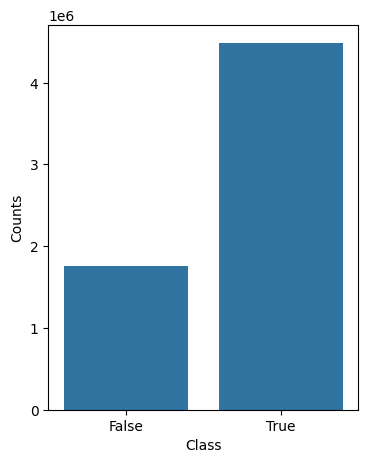

In [9]:
#Visualizations 

class_counts = np.bincount(df["Parkinsons"])

plt.figure(figsize=(4,5))
sns.barplot(x = np.unique(df["Parkinsons"]), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [10]:
#Importing modules
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [11]:
#Defining the features and labels for dataset 
y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons", "Gender_Male"])

In [12]:
#Oversampling the minority class in PD
from imblearn.over_sampling import SMOTE

X_train_raw, X_test, y_train_raw , y_test = train_test_split(X, y, random_state=42, test_size=0.3)


#Calling the class, passing in parameters of constructor and fitting in 
smote = SMOTE(random_state= 42)

X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [13]:
print(X_train.columns.tolist())

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


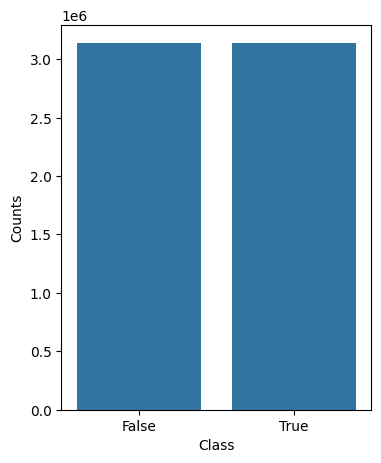

In [14]:
#Visualizations of the PD class after SMOTE
import numpy as np
class_counts = np.bincount(y_train)

plt.figure(figsize=(4, 5))
sns.barplot(x = np.unique(y_train), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [15]:
#Defining hyperparameters in dict-like form

model_lgbm = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5)

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
#Fitting the model, training and performing evaluation

model_lgbm.fit(X_train, y_train)

model_lgbm.predict_proba(X_test)

pred = model_lgbm.predict(X_test)

score = model_lgbm.score(X_train, y_train)

acc_score = accuracy_score(y_test, pred)


[LightGBM] [Info] Number of positive: 3138224, number of negative: 3138224
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 6276448, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [18]:
acc_score

0.6735373388709166

In [19]:
print("Accuracy on the train set", score)

print("Accuracy on the test set", model_lgbm.score(X_test, y_test))

Accuracy on the train set 0.6990746995753012
Accuracy on the test set 0.6735373388709166


In [20]:
#Confusion matrix and classification matrix
cm = confusion_matrix(y_test, pred)
print(cm)

class_report = classification_report(y_test, pred)
print(class_report)

[[337846 187426]
 [423416 922405]]
              precision    recall  f1-score   support

       False       0.44      0.64      0.53    525272
        True       0.83      0.69      0.75   1345821

    accuracy                           0.67   1871093
   macro avg       0.64      0.66      0.64   1871093
weighted avg       0.72      0.67      0.69   1871093



<Axes: title={'center': 'Plot of feature importance'}, xlabel='Feature importance', ylabel='Features'>

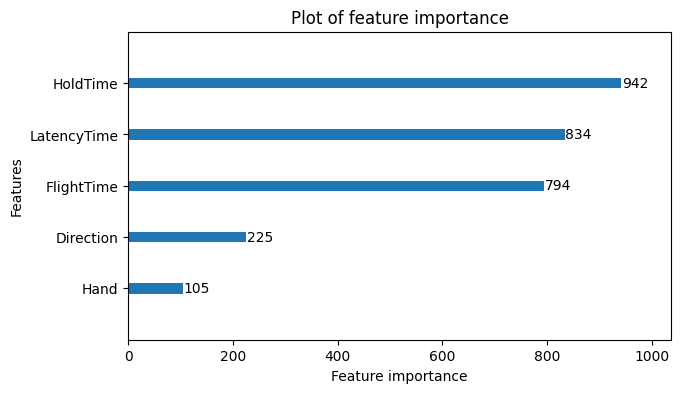

In [21]:
#Plotting important features
lgb.plot_importance(model_lgbm, title="Plot of feature importance", figsize=(7,4), grid=False )

In [22]:
model_lgbm.feature_importances_

array([105, 942, 225, 834, 794], dtype=int32)

Text(0.5, 1.0, 'ROC plot')

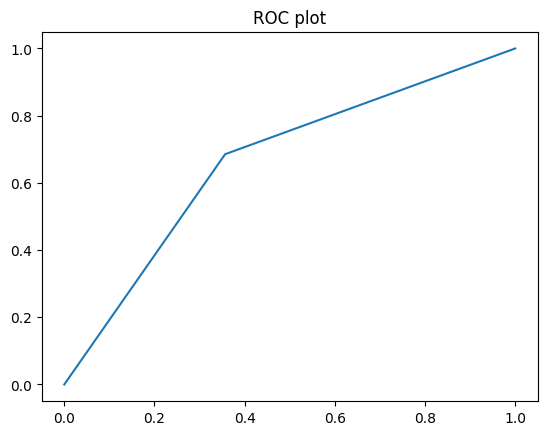

In [23]:
#Plotting roc-curve

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, pred )

sns.lineplot(x=fpr, y=tpr)

plt.title("ROC plot")

Retraining the model with only the most impactful features, so dropping hand and direction

In [24]:
df_new = df.drop(columns = ["Hand", "Gender_Male"])

In [25]:
df_new

,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons
0,101.6,0,234.4,156.3,True
1,85.9,0,437.5,359.4,True
2,78.1,0,210.9,125.0,True
3,62.5,0,359.4,281.3,True
4,85.9,1,195.3,117.2,True
...,...,...,...,...,...
6236971,195.3,2,425.8,261.7,True
6236972,105.5,1,214.8,19.5,True
6236973,168.0,0,332.0,15.6,True
6236974,97.7,0,281.3,113.3,True


In [26]:
#Defining labels and features, and input vectors
y_final = df_new["Parkinsons"]

X_final = df_new.drop(columns=["Parkinsons"])

X_train_new, X_test_final, y_train_new, y_test_final = train_test_split(X_final, y_final, random_state=42, test_size=0.3)

smote_final = SMOTE(random_state = 42)

X_train_final, y_train_final = smote_final.fit_resample(X_train_new, y_train_new)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [27]:
print("Train columns:", X_train_final.columns.tolist())
print("Test columns:", X_test_final.columns.tolist())

Train columns: ['HoldTime', 'Direction', 'LatencyTime', 'FlightTime']
Test columns: ['HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


In [28]:
model_final = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5)

In [29]:
#Fitting the model, evaluating the model, 
model_final.fit(X_train_final, y_train_final)

final_pred = model_final.predict(X_test_final)

score_final = model_final.score(X_train_final, y_train_final)


[LightGBM] [Info] Number of positive: 3138224, number of negative: 3138224
[LightGBM] [Info] Total Bins 767
[LightGBM] [Info] Number of data points in the train set: 6276448, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [30]:
#Printing the evalutaion metrics
print(accuracy_score(y_test, final_pred))
print()

print(confusion_matrix(y_test, final_pred))
print()

print(confusion_matrix(y_test, final_pred))
print()

0.6627976268416375

[[349938 175334]
 [455603 890218]]

[[349938 175334]
 [455603 890218]]



Hyperparameter tuning with GridSearchCV


In [31]:
from sklearn.model_selection import GridSearchCV, KFold

In [33]:
#Cross validation 
kfold = KFold(n_splits=5, random_state = 42, shuffle=True)

param_grid = {
    "num_leaves": [np.arange(5, 30, 5).tolist()],
    "max_depth": [np.arange(4, 12, 4).tolist()],
    "learning_rate": [0.01, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8,0.9],
    "bagging_fraction":[0.7, 0.8, 0.9]
}

grid = GridSearchCV(estimator=model_final, param_grid=param_grid, cv=kfold)

In [ ]:
grid.fit(X_train_final, y_train_final)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7


[LightGBM] [Fatal] Parameter num_leaves should be of type int, got "5,10,15,20,25"


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7


[LightGBM] [Fatal] Parameter num_leaves should be of type int, got "5,10,15,20,25"


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7


...

[LightGBM] [Fatal] Parameter num_leaves should be of type int, got "5,10,15,20,25"


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


[LightGBM] [Fatal] Parameter num_leaves should be of type int, got "5,10,15,20,25"


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


[LightGBM] [Fatal] Parameter num_leaves should be of type int, got "5,10,15,20,25"
